In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

prices      = pd.read_csv("../data/dax_prices.csv")
fin_df      = pd.read_csv("../data/dax_financials.csv")
covid_df    = pd.read_csv("../data/covid_recovery.csv")
sector_kpis = pd.read_csv("../data/sector_kpis.csv")

print("Datos cargados OK")

Datos cargados OK


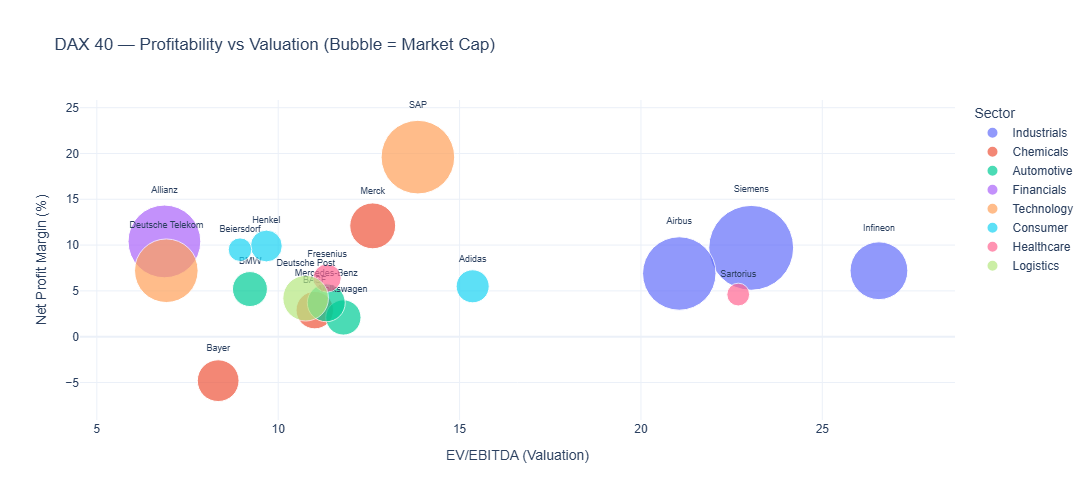

In [2]:
fin_clean = fin_df.copy()
fin_clean["gross_margins"]    = (fin_clean["gross_margins"]    * 100).round(1)
fin_clean["profit_margins"]   = (fin_clean["profit_margins"]   * 100).round(1)
fin_clean["revenue_growth"]   = (fin_clean["revenue_growth"]   * 100).round(1)
fin_clean["return_on_equity"] = (fin_clean["return_on_equity"] * 100).round(1)

# Filtrar nulos para el bubble chart
bubble = fin_clean.dropna(subset=["ev_ebitda", "profit_margins", "market_cap"])

fig = px.scatter(
    bubble,
    x="ev_ebitda",
    y="profit_margins",
    size="market_cap",
    color="sector",
    text="company",
    title="DAX 40 — Profitability vs Valuation (Bubble = Market Cap)",
    labels={
        "ev_ebitda":      "EV/EBITDA (Valuation)",
        "profit_margins": "Net Profit Margin (%)",
        "sector":         "Sector"
    },
    size_max=60
)

fig.update_traces(textposition="top center", textfont_size=9)
fig.update_layout(
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=500
)

fig.show()

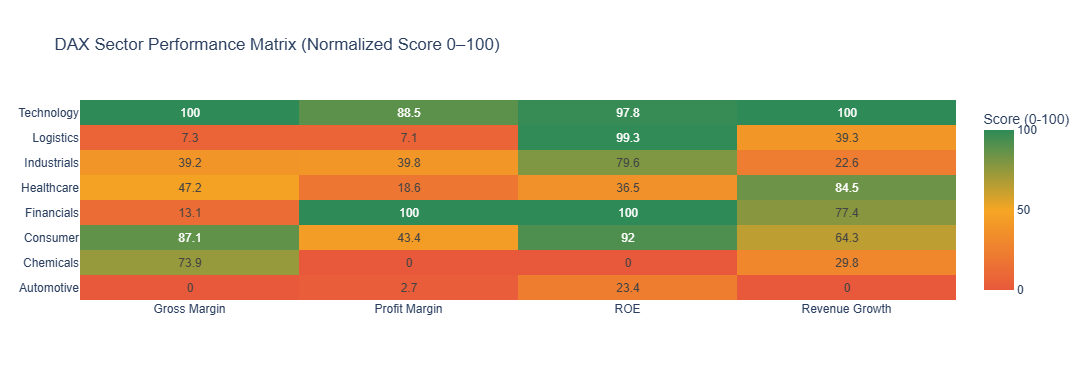

In [3]:
# Crear matriz de scores normalizados por sector
metrics = ["avg_gross_margin", "avg_profit_margin", "avg_roe",
           "avg_revenue_growth"]
labels  = ["Gross Margin", "Profit Margin", "ROE", "Revenue Growth"]

matrix = sector_kpis.set_index("sector")[metrics].copy()

# Normalizar cada métrica 0-100
for col in metrics:
    mn = matrix[col].min()
    mx = matrix[col].max()
    matrix[col] = ((matrix[col] - mn) / (mx - mn) * 100).round(1)

fig2 = go.Figure(go.Heatmap(
    z=matrix.values,
    x=labels,
    y=matrix.index.tolist(),
    colorscale=[[0, "#E8593C"], [0.5, "#F5A623"], [1, "#2E8B57"]],
    text=matrix.values.round(1),
    texttemplate="%{text}",
    showscale=True,
    colorbar=dict(title="Score (0-100)")
))

fig2.update_layout(
    title="DAX Sector Performance Matrix (Normalized Score 0–100)",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=380
)

fig2.show()

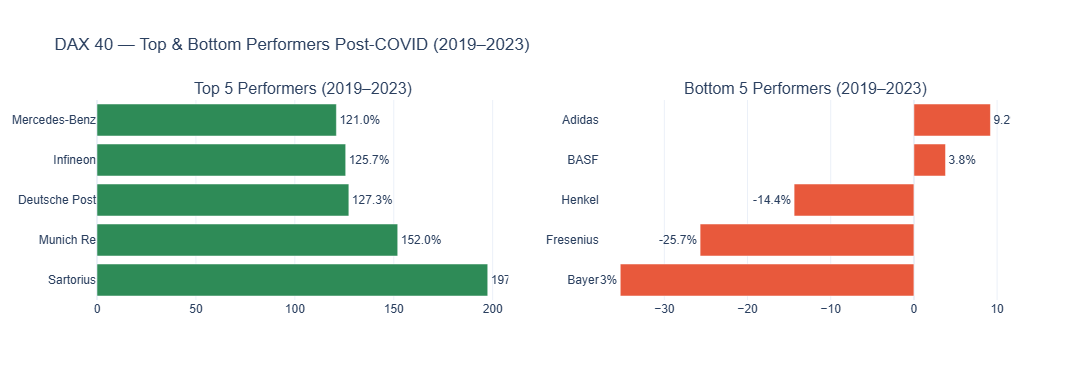

In [4]:
# Top 5 y bottom 5 por total return
top5    = covid_df.nlargest(5,  "total_return_pct")[["company", "sector", "total_return_pct"]]
bottom5 = covid_df.nsmallest(5, "total_return_pct")[["company", "sector", "total_return_pct"]]

fig3 = make_subplots(rows=1, cols=2,
    subplot_titles=(
        "Top 5 Performers (2019–2023)",
        "Bottom 5 Performers (2019–2023)"
    ))

fig3.add_trace(go.Bar(
    x=top5["total_return_pct"],
    y=top5["company"],
    orientation="h",
    marker_color="#2E8B57",
    showlegend=False,
    text=top5["total_return_pct"].astype(str) + "%",
    textposition="outside"
), row=1, col=1)

fig3.add_trace(go.Bar(
    x=bottom5["total_return_pct"],
    y=bottom5["company"],
    orientation="h",
    marker_color="#E8593C",
    showlegend=False,
    text=bottom5["total_return_pct"].astype(str) + "%",
    textposition="outside"
), row=1, col=2)

fig3.update_layout(
    title="DAX 40 — Top & Bottom Performers Post-COVID (2019–2023)",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=380
)

fig3.show()

In [5]:
best_sector  = sector_kpis.loc[sector_kpis["avg_revenue_growth"].idxmax(), "sector"]
worst_sector = sector_kpis.loc[sector_kpis["avg_revenue_growth"].idxmin(), "sector"]
best_margin  = sector_kpis.loc[sector_kpis["avg_gross_margin"].idxmax(),   "sector"]
best_roe     = sector_kpis.loc[sector_kpis["avg_roe"].idxmax(),            "sector"]
best_company = covid_df.loc[covid_df["total_return_pct"].idxmax(),         "company"]
worst_company= covid_df.loc[covid_df["total_return_pct"].idxmin(),         "company"]

print("=" * 62)
print("DAX 40 FINANCIAL PERFORMANCE ANALYSIS — EXECUTIVE SUMMARY")
print("Period: 2019–2023 | Universe: 20 DAX Companies")
print("=" * 62)

print(f"""
SECTOR RANKINGS

  Fastest Recovery Post-COVID:
    → {best_sector} sector — highest revenue growth
    → Technology: highest gross margins ({sector_kpis[sector_kpis['sector']=='Technology']['avg_gross_margin'].values[0]:.1f}%)
    → {best_roe}: highest return on equity

  Structural Underperformers:
    → {worst_sector} sector — negative revenue growth
    → Automotive: lowest gross margins (14.2%) and ROE (5.2%)
    → Chemicals: dragged down by Bayer litigation + BASF restructuring

COMPANY HIGHLIGHTS

  Best performer:  {best_company}
    → +{covid_df[covid_df['company']==best_company]['total_return_pct'].values[0]:.1f}% total return
    → Beneficiary of COVID biotech/lab equipment boom

  Worst performer: {worst_company}
    → {covid_df[covid_df['company']==worst_company]['total_return_pct'].values[0]:.1f}% total return
    → Structural headwinds: litigation risk + patent cliff

KEY INSIGHTS FOR CONTROLLING & FP&A

  1. Technology and Healthcare show the strongest combination
     of margin quality and growth — ideal for long-term investment.

  2. Automotive faces a structural margin squeeze from EV transition
     — capex intensity rising while pricing power erodes.

  3. Chemicals sector recovery is uneven — Merck outperforms
     while Bayer and BASF face company-specific headwinds.

  4. COVID recovery speed was inversely correlated with
     initial drop size — companies that fell hardest
     (Mercedes -38%, Infineon -30%) recovered fastest.

  5. Financial sector shows highest ROE (15.7%) but lowest
     EV/EBITDA (6.9x) — potentially undervalued relative
     to profitability.
""")
print("=" * 62)

DAX 40 FINANCIAL PERFORMANCE ANALYSIS — EXECUTIVE SUMMARY
Period: 2019–2023 | Universe: 20 DAX Companies

SECTOR RANKINGS

  Fastest Recovery Post-COVID:
    → Technology sector — highest revenue growth
    → Technology: highest gross margins (59.1%)
    → Financials: highest return on equity

  Structural Underperformers:
    → Automotive sector — negative revenue growth
    → Automotive: lowest gross margins (14.2%) and ROE (5.2%)
    → Chemicals: dragged down by Bayer litigation + BASF restructuring

COMPANY HIGHLIGHTS

  Best performer:  Sartorius
    → +197.5% total return
    → Beneficiary of COVID biotech/lab equipment boom

  Worst performer: Bayer
    → -35.3% total return
    → Structural headwinds: litigation risk + patent cliff

KEY INSIGHTS FOR CONTROLLING & FP&A

  1. Technology and Healthcare show the strongest combination
     of margin quality and growth — ideal for long-term investment.

  2. Automotive faces a structural margin squeeze from EV transition
     — capex

In [6]:
fin_clean.to_csv("../data/dax_financials_clean.csv", index=False)
print("Guardado OK")

Guardado OK
